In [2]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline

In [3]:
data = pd.read_csv("book_reviews_sample.csv")

In [4]:
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [5]:
data["reviewText_clean"] = data["reviewText"].str.lower()

In [6]:
data["reviewText_clean"] = data["reviewText_clean"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

In [7]:
data.head()

,index,reviewText,rating,reviewText_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [8]:
vader_sentiment = SentimentIntensityAnalyzer()

In [14]:
data["vader_sentiment_scores"] = data["reviewText_clean"].apply(lambda x: vader_sentiment.polarity_scores(x)["compound"])

In [15]:
data.head()

,index,reviewText,rating,reviewText_clean,vader_sentiment_scores
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [16]:
bins = [-1, -0.1, 0.1, 1]
names = ["negative", "neutral", "postiive"]

In [17]:
data["vader_sentiment_score_label"] = pd.cut(data["vader_sentiment_scores"], bins, labels=names)

In [18]:
data.head()

,index,reviewText,rating,reviewText_clean,vader_sentiment_scores,vader_sentiment_score_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,postiive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,postiive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,postiive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,postiive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative


<Axes: xlabel='vader_sentiment_score_label'>

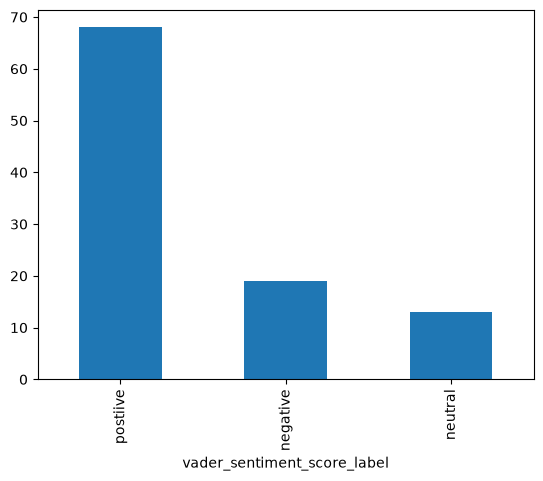

In [20]:
data["vader_sentiment_score_label"].value_counts().plot.bar()

In [21]:
transformer_pipeline = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [24]:
transformer_labels = []

for review in data["reviewText_clean"].values:
    sentiment_list = transformer_pipeline(review)
    sentiment_label = [sentiment["label"] for sentiment in sentiment_list]
    transformer_labels.append(sentiment_label)

In [25]:
data["transformer_sentiment_label"] = transformer_labels

<Axes: xlabel='transformer_sentiment_label'>

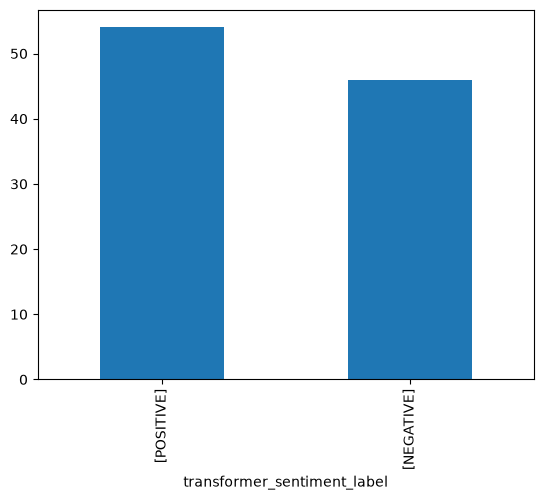

In [26]:
data["transformer_sentiment_label"].value_counts().plot.bar()